# 🥇 Competición de Predicción del Precio del Oro
## Feature Engineering Challenge — Series Temporales Financieras

---

### 📋 Descripción de la Competición

El objetivo de esta competición es **predecir el precio de cierre diario del oro (XAU/USD)** mediante técnicas de feature engineering. El modelo (XGBoost) está fijado — vuestra ventaja competitiva estará en la **calidad de las variables que construyáis**.

### 📌 Reglas

| Parámetro | Detalle |
|---|---|
| **Variable objetivo** | `Close` (precio de cierre diario del oro) |
| **Modelo** | XGBoost (fijado — no se puede cambiar) |
| **Período de test** | 01/02/2026 → 31/03/2026 (2 meses fijos) |
| **Período de train** | Libre — podéis elegir cuánta historia usar |
| **Métrica** | RMSE + MAE + R² sobre el conjunto de test |
| **Entregable** | Este notebook completado + tabla de features |

### 🏆 Puntuación

- **60%** → Rendimiento del modelo en test (RMSE más bajo gana)
- **30%** → Calidad y originalidad de las features creadas
- **10%** → Claridad de la explicación de vuestras decisiones

### ⚠️ Importante

> **Data Leakage**: No podéis usar información futura para construir features. Todo lo que calculéis debe poder calcularse en tiempo real (usando solo datos hasta el día $t-1$).

---

## 0. Instalación y Librerías

In [1]:
# Instalamos las librerías necesarias (ejecutar solo si no están instaladas)
# !pip install yfinance xgboost shap matplotlib seaborn pandas numpy scikit-learn

import warnings
warnings.filterwarnings('ignore')

# Librerías de datos
import pandas as pd
import numpy as np
import yfinance as yf

# Visualización
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Modelado
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import shap

# Configuración de estilo
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 50)

# Semilla para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('✅ Librerías cargadas correctamente')
print(f'   pandas   : {pd.__version__}')
print(f'   numpy    : {np.__version__}')
print(f'   yfinance : {yf.__version__}')

✅ Librerías cargadas correctamente
   pandas   : 3.0.2
   numpy    : 2.4.4
   yfinance : 1.3.0


---
## 1. Descarga de Datos

Descargamos el precio diario del oro desde Yahoo Finance usando el ticker `GC=F` (Gold Futures). 

El **conjunto de test está fijado**: del **01/02/2026 al 31/03/2026**. 
Podéis elegir cuánta historia usar para entrenamiento — más datos no siempre significa mejor modelo.

In [2]:
# ============================================================
# PARÁMETROS FIJOS DE LA COMPETICIÓN — NO MODIFICAR
# ============================================================
TEST_START  = '2026-02-01'
TEST_END    = '2026-03-31'
TICKER      = 'GC=F'       # Gold Futures en Yahoo Finance

# ============================================================
# PARÁMETRO LIBRE — PODÉIS MODIFICAR
# ============================================================
TRAIN_START = '2020-01-01'  # ← Cambiad esta fecha para usar más o menos historia

# Descarga de datos
print(f'📥 Descargando datos de {TICKER} desde {TRAIN_START} hasta {TEST_END}...')
raw_data = yf.download(TICKER, start=TRAIN_START, end=TEST_END, progress=False)

# Aplanamos columnas MultiIndex si existen
if isinstance(raw_data.columns, pd.MultiIndex):
    raw_data.columns = raw_data.columns.get_level_values(0)

raw_data.index = pd.to_datetime(raw_data.index)
raw_data = raw_data.sort_index()

print(f'✅ Datos descargados correctamente')
print(f'   Rango     : {raw_data.index[0].date()} → {raw_data.index[-1].date()}')
print(f'   Filas     : {len(raw_data):,}')
print(f'   Columnas  : {list(raw_data.columns)}')

raw_data.tail(5)

📥 Descargando datos de GC=F desde 2020-01-01 hasta 2026-03-31...
✅ Datos descargados correctamente
   Rango     : 2020-01-02 → 2026-03-30
   Filas     : 1,570
   Columnas  : ['Close', 'High', 'Low', 'Open', 'Volume']


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-03-24,4399.2998,4399.2998,4325.2002,4338.7002,378
2026-03-25,4549.7998,4551.8999,4541.7998,4549.0000,388
2026-03-26,4375.5000,4443.1001,4375.5000,4441.5000,1070
2026-03-27,4492.0000,4492.0000,4492.0000,4492.0000,74348
2026-03-30,4526.0000,4579.1001,4413.3999,4482.7998,10816


---
## 2. Análisis Exploratorio de Datos (EDA)

Antes de construir features, es crucial entender la serie. En esta sección:
- Visualizamos la evolución del precio
- Analizamos la distribución de retornos
- Estudiamos la estacionalidad y autocorrelación
- Detectamos posibles outliers

In [3]:
# ── 2.1 Vista general de los datos ───────────────────────────────────────────
print('=' * 60)
print('ESTADÍSTICAS DESCRIPTIVAS — PRECIO DE CIERRE')
print('=' * 60)
print(raw_data['Close'].describe().to_string())
print(f'\nValores nulos : {raw_data["Close"].isna().sum()}')
print(f'Valores únicos: {raw_data["Close"].nunique():,}')

ESTADÍSTICAS DESCRIPTIVAS — PRECIO DE CIERRE
count   1570.0000
mean    2294.3731
std      814.9426
min     1477.3000
25%     1798.4500
50%     1927.5000
75%     2512.2501
max     5318.3999

Valores nulos : 0
Valores únicos: 1,444


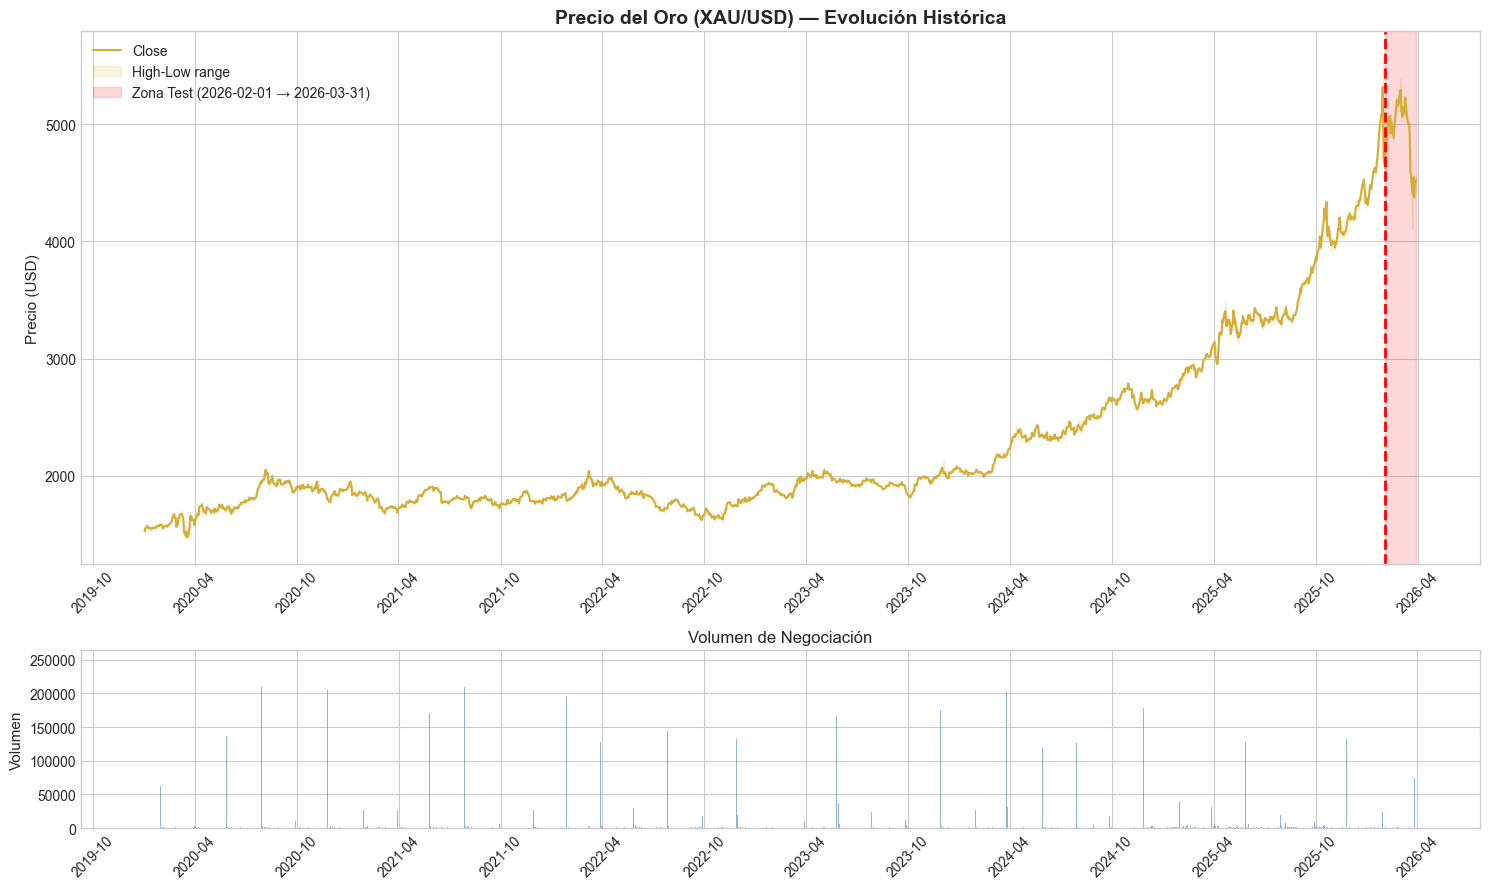

💡 La línea roja separa entrenamiento (izquierda) del test (derecha)


In [4]:
# ── 2.2 Serie temporal completa ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(15, 9), gridspec_kw={'height_ratios': [3, 1]})

# Precio de cierre
ax1 = axes[0]
ax1.plot(raw_data.index, raw_data['Close'], color='#D4AF37', linewidth=1.5, label='Close')
ax1.fill_between(raw_data.index, raw_data['Low'], raw_data['High'], 
                  alpha=0.15, color='#D4AF37', label='High-Low range')

# Zona de test
test_mask = raw_data.index >= TEST_START
ax1.axvspan(pd.Timestamp(TEST_START), raw_data.index[-1], 
             alpha=0.15, color='red', label=f'Zona Test ({TEST_START} → {TEST_END})')
ax1.axvline(pd.Timestamp(TEST_START), color='red', linestyle='--', linewidth=2)

ax1.set_title('Precio del Oro (XAU/USD) — Evolución Histórica', fontsize=14, fontweight='bold')
ax1.set_ylabel('Precio (USD)', fontsize=11)
ax1.legend(loc='upper left', fontsize=10)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# Volumen
ax2 = axes[1]
ax2.bar(raw_data.index, raw_data['Volume'], color='steelblue', alpha=0.6, width=1)
ax2.set_ylabel('Volumen', fontsize=11)
ax2.set_title('Volumen de Negociación', fontsize=12)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('eda_serie_temporal.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 La línea roja separa entrenamiento (izquierda) del test (derecha)')

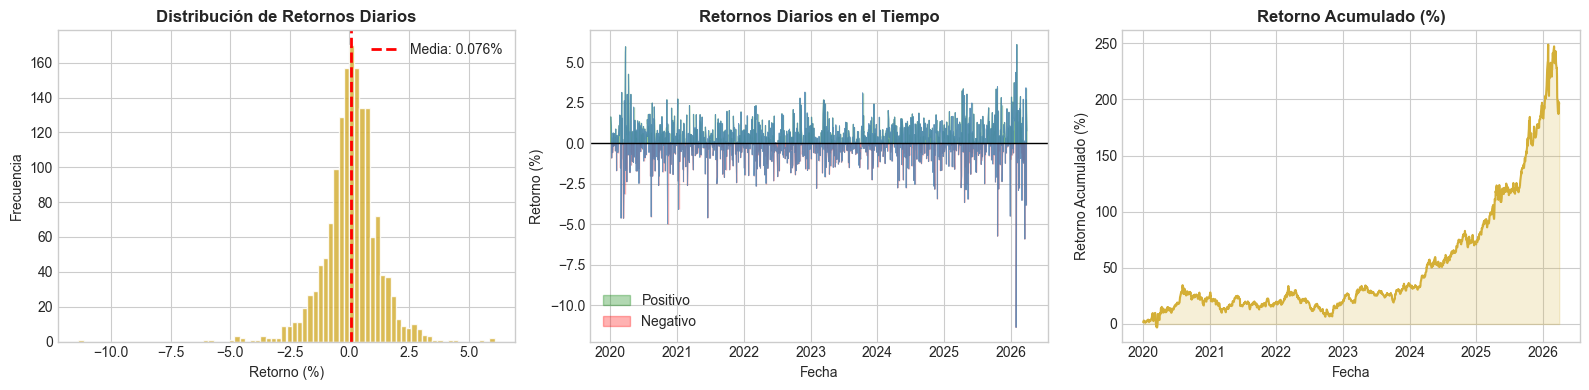


📊 Estadísticas de Retornos Diarios:
   Media      : 0.0763%
   Volatilidad: 1.1690%
   Mínimo     : -11.3662%
   Máximo     : 6.0833%
   Asimetría  : -0.8114
   Curtosis   : 8.7462


In [5]:
# ── 2.3 Retornos diarios ────────────────────────────────────────────────────
returns = raw_data['Close'].pct_change().dropna() * 100  # en %

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histograma de retornos
axes[0].hist(returns, bins=80, color='#D4AF37', edgecolor='white', alpha=0.85)
axes[0].axvline(returns.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {returns.mean():.3f}%')
axes[0].set_title('Distribución de Retornos Diarios', fontweight='bold')
axes[0].set_xlabel('Retorno (%)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Retornos en el tiempo
axes[1].plot(returns.index, returns, color='steelblue', linewidth=0.7, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].fill_between(returns.index, returns, where=(returns >= 0), color='green', alpha=0.3, label='Positivo')
axes[1].fill_between(returns.index, returns, where=(returns < 0), color='red', alpha=0.3, label='Negativo')
axes[1].set_title('Retornos Diarios en el Tiempo', fontweight='bold')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Retorno (%)')
axes[1].legend()

# Retorno acumulado
cum_return = (1 + returns / 100).cumprod() - 1
axes[2].plot(cum_return.index, cum_return * 100, color='#D4AF37', linewidth=1.5)
axes[2].fill_between(cum_return.index, cum_return * 100, alpha=0.2, color='#D4AF37')
axes[2].set_title('Retorno Acumulado (%)', fontweight='bold')
axes[2].set_xlabel('Fecha')
axes[2].set_ylabel('Retorno Acumulado (%)')

plt.tight_layout()
plt.savefig('eda_retornos.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Estadísticas de Retornos Diarios:')
print(f'   Media      : {returns.mean():.4f}%')
print(f'   Volatilidad: {returns.std():.4f}%')
print(f'   Mínimo     : {returns.min():.4f}%')
print(f'   Máximo     : {returns.max():.4f}%')
print(f'   Asimetría  : {returns.skew():.4f}')
print(f'   Curtosis   : {returns.kurt():.4f}')

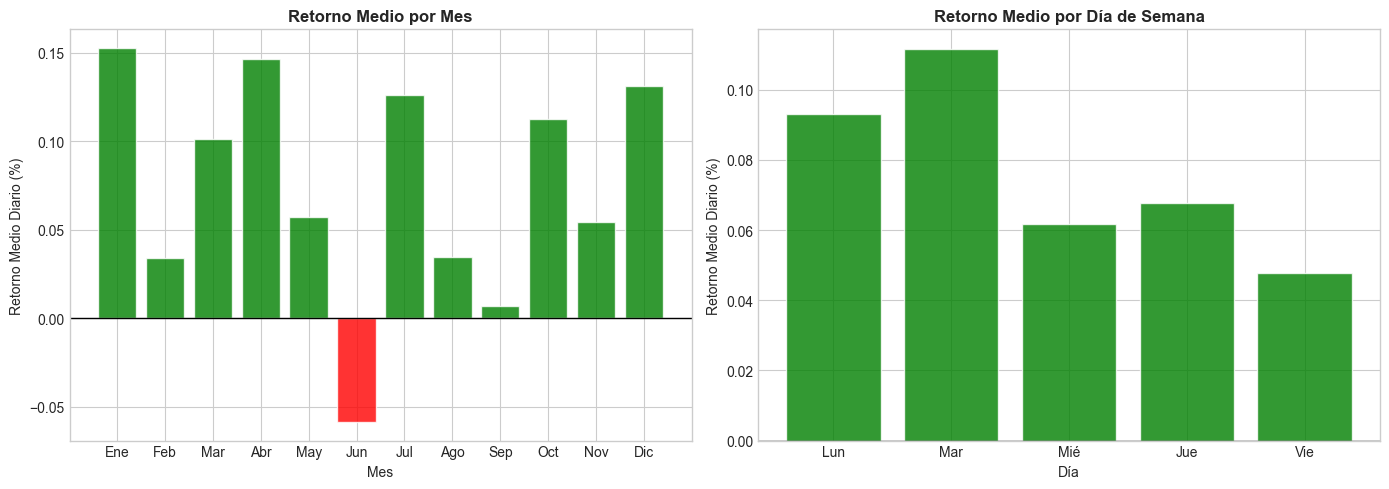

💡 ¿Veis patrones estacionales? Esto puede inspirar features de calendario


In [6]:
# ── 2.4 Análisis de estacionalidad por mes y día de semana ──────────────────
df_eda = raw_data.copy()
df_eda['returns'] = df_eda['Close'].pct_change() * 100
df_eda['month']   = df_eda.index.month
df_eda['weekday'] = df_eda.index.dayofweek  # 0=Lunes, 4=Viernes
df_eda['year']    = df_eda.index.year

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

month_names = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
monthly_ret = df_eda.groupby('month')['returns'].mean()
colors_m = ['green' if x >= 0 else 'red' for x in monthly_ret]
axes[0].bar(month_names, monthly_ret.values, color=colors_m, alpha=0.8, edgecolor='white')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Retorno Medio por Mes', fontweight='bold')
axes[0].set_ylabel('Retorno Medio Diario (%)')
axes[0].set_xlabel('Mes')

day_names = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie']
daily_ret = df_eda.groupby('weekday')['returns'].mean()
colors_d = ['green' if x >= 0 else 'red' for x in daily_ret]
axes[1].bar(day_names, daily_ret.values, color=colors_d, alpha=0.8, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Retorno Medio por Día de Semana', fontweight='bold')
axes[1].set_ylabel('Retorno Medio Diario (%)')
axes[1].set_xlabel('Día')

plt.tight_layout()
plt.savefig('eda_estacionalidad.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 ¿Veis patrones estacionales? Esto puede inspirar features de calendario')

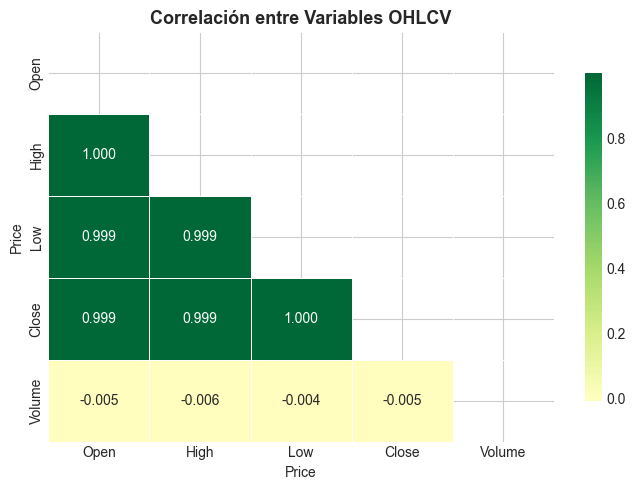

💡 Open, High, Low y Close están muy correlacionadas — los retornos suelen ser más informativos


In [7]:
# ── 2.5 Correlación de columnas OHLCV ────────────────────────────────────────
corr_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
corr_matrix = raw_data[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, ax=ax, mask=mask, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlación entre Variables OHLCV', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('eda_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Open, High, Low y Close están muy correlacionadas — los retornos suelen ser más informativos')

---
## 3. Feature Engineering — Features de Ejemplo

A continuación construimos un conjunto de features de ejemplo. Estas features son el **punto de partida** — vuestro trabajo es mejorarlas, combinarlas o crear otras completamente nuevas.

### Tipos de features más comunes en series temporales financieras:

| Categoría | Ejemplos |
|---|---|
| **Lag features** | Precio de hace 1, 5, 10 días |
| **Medias móviles** | SMA, EMA de distintas ventanas |
| **Volatilidad** | Desviación estándar de retornos |
| **Momentum** | RSI, MACD, ROC |
| **Velas** | Rango diario, body size, sombras |
| **Calendario** | Día de semana, mes, trimestre |
| **Cruce de medias** | Golden cross, señales de cruce |

> ⚠️ **Recordad**: toda feature debe calcularse usando solo datos hasta $t-1$ para evitar data leakage.

In [8]:
def build_features(df):
    """
    Construye el conjunto de features a partir de datos OHLCV.
    
    IMPORTANTE: Todas las features deben ser calculables con datos
    disponibles hasta t-1 (sin mirar al futuro).
    
    Parameters:
    -----------
    df : pd.DataFrame con columnas Open, High, Low, Close, Volume
    
    Returns:
    --------
    pd.DataFrame con todas las features + columna 'target'
    """
    data = df.copy()
    
    # ── Target ──────────────────────────────────────────────────────────────
    # Predecimos el precio de cierre del DÍA SIGUIENTE
    # Nota: shift(-1) hace que en la fila de hoy tengamos el close de mañana
    data['target'] = data['Close'].shift(-1)
    
    # ── [A] RETORNOS ─────────────────────────────────────────────────────────
    data['return_1d']  = data['Close'].pct_change(1)
    data['return_2d']  = data['Close'].pct_change(2)
    
    # ── [B] LAG FEATURES (precio absoluto desplazado) ────────────────────────
    for lag in [1, 2, 3, 5]:
        data[f'close_lag_{lag}'] = data['Close'].shift(lag)
    
    # ── [C] MEDIAS MÓVILES SIMPLES (SMA) ────────────────────────────────────
    for window in [5, 10]:
        data[f'sma_{window}'] = data['Close'].rolling(window).mean()
    
    # ── [D] MEDIAS MÓVILES EXPONENCIALES (EMA) ───────────────────────────────
    for span in [2, 3, 5]:
        data[f'ema_{span}'] = data['Close'].ewm(span=span, adjust=False).mean()
    
    # ── [E] VOLATILIDAD (desviación estándar de retornos) ────────────────────
    data['vol_5d']  = data['return_1d'].rolling(5).std()
    data['vol_10d'] = data['return_1d'].rolling(10).std()
    
    # ── [F] INDICADORES TÉCNICOS ─────────────────────────────────────────────
    
    # RSI (Relative Strength Index) — ventana 14 días
    delta = data['Close'].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rs    = gain / (loss + 1e-10)
    data['rsi_14'] = 100 - (100 / (1 + rs))
    
    # ── [G] FEATURES DE VELA (candlestick) ───────────────────────────────────
    data['candle_range']  = (data['High'] - data['Low']) / (data['Close'] + 1e-10)
    data['candle_body']   = (data['Close'] - data['Open']) / (data['Open'] + 1e-10)
    
    # ── [H] FEATURES DE VOLUMEN ──────────────────────────────────────────────
    data['vol_sma5']   = data['Volume'].rolling(5).mean()
    data['vol_change'] = data['Volume'].pct_change()
    
    # ── [I] FEATURES DE CALENDARIO ───────────────────────────────────────────
    data['day_of_week']    = data.index.dayofweek       # 0=Lunes, 4=Viernes
    data['month']          = data.index.month
    data['quarter']        = data.index.quarter
    data['day_of_year']    = data.index.dayofyear
    data['week_of_year']   = data.index.isocalendar().week.astype(int)
    data['is_month_start'] = data.index.is_month_start.astype(int)
    data['is_month_end']   = data.index.is_month_end.astype(int)
    
    # ── [J] RATIOS PRECIO / MEDIA MÓVIL ─────────────────────────────────────
    data['price_sma5_ratio']  = data['Close'] / (data['sma_5'] + 1e-10)
    data['price_sma10_ratio'] = data['Close'] / (data['sma_10'] + 1e-10)
    
    return data


# Construimos las features
df_features = build_features(raw_data)

# Descartamos filas con NaN (producidas por rolling windows, etc.)
df_features = df_features.dropna()

print(f'✅ Features construidas')
print(f'   Filas totales (tras dropna): {len(df_features):,}')
print(f'   Número de columnas          : {len(df_features.columns)}')
print(f'   Rango temporal              : {df_features.index[0].date()} → {df_features.index[-1].date()}')

# Listado de features disponibles
feature_cols = [c for c in df_features.columns if c not in 
                ['Open','High','Low','Close','Volume','target']]
print(f'\n📋 Features disponibles ({len(feature_cols)}):')
for i, f in enumerate(feature_cols):
    print(f'   [{i+1:02d}] {f}')

✅ Features construidas
   Filas totales (tras dropna): 1,554
   Número de columnas          : 33
   Rango temporal              : 2020-01-23 → 2026-03-27

📋 Features disponibles (27):
   [01] return_1d
   [02] return_2d
   [03] close_lag_1
   [04] close_lag_2
   [05] close_lag_3
   [06] close_lag_5
   [07] sma_5
   [08] sma_10
   [09] ema_2
   [10] ema_3
   [11] ema_5
   [12] vol_5d
   [13] vol_10d
   [14] rsi_14
   [15] candle_range
   [16] candle_body
   [17] vol_sma5
   [18] vol_change
   [19] day_of_week
   [20] month
   [21] quarter
   [22] day_of_year
   [23] week_of_year
   [24] is_month_start
   [25] is_month_end
   [26] price_sma5_ratio
   [27] price_sma10_ratio


---
## 4. 🔨 Zona de Trabajo de los Alumnos

**¡Aquí empieza vuestra parte!** Añadid vuestras propias features en la función de abajo.

### Ideas para explorar:

- **Indicadores técnicos adicionales**: Stochastic RSI, ATR (Average True Range), OBV (On-Balance Volume), CCI, Williams %R...
- **Features de interacción**: combinaciones de indicadores existentes, ratios entre medias de distinto plazo...
- **Medias móviles no lineales**: DEMA, TEMA, Kaufman Adaptive Moving Average...
- **Features de régimen de mercado**: detectar si el mercado está en tendencia o lateral (ADX)...
- **Lookback asimétrico**: ¿los retornos de los últimos 3 días positivos/negativos tienen diferente impacto?
- **Correlación con otros activos**: dólar (DXY), bonos (TLT), plata (SI=F)... *(descarga con yfinance)*
- **Noticias / sentimiento**: si tenéis acceso a datos externos...
- **Transformaciones del precio**: log-precio, diferenciación...

### Instrucciones:
1. Añadid vuestras features en la función `build_my_features()` de abajo
2. Llamad a `build_my_features()`, meter aquí todas las features que querais, incluidas las de ejemplo de arriba, recordar que las que tendremos en cuenta serán las que hagais vosotros.
3. El modelo usará **todas** las features que devuelva la función
4. Documentad brevemente qué calcula cada feature y por qué creéis que puede ayudar

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
#  ✏️  FUNCIÓN A COMPLETAR POR LOS ALUMNOS
# ════════════════════════════════════════════════════════════════════════════

def build_my_features(df):
    """
    Añadid aquí vuestras features personalizadas.
    """
    data = df.copy()
    
    # ─────────────────────────────────────────────────────────────────────

    # Z-Score de los ultimos 20 dias
    # A su vez, nos indica cuanto de inusaual es el precio actual
    media_20 = data['Close'].rolling(20).mean()
    std_20 = data['Close'].rolling(20).std()
    data['z_score_20'] = (data['Close'] - media_20) / (std_20 + 1e-10)

    # Retorno la ultima semana
    # Indica tendencias, si la semana ha tenido una tendencia creciente, estable o decreciente.
    data['retorno_5d'] = data['Close'].pct_change(5)

    # Precio maximo ultimos 20 dias
    # Calcula la relacion entre el precio de cierre de hoy y el precio mas alto de las ultimas 4 semanas.
    max_20d = data['High'].rolling(20).max()
    data['distancia_max_20d'] = data['Close'] / (max_20d + 1e-10)
    # ─────────────────────────────────────────────────────────────────────
    
    return data

# ─── Aplicamos las features de los alumnos ──────────────────────────────────
# ¡CORRECCIÓN CRÍTICA! Usamos df_features, NO raw_data
df_all = build_my_features(df_features) 
df_all = df_all.dropna()   # eliminamos NaN generados por rolling windows

# Limpiamos inf/-inf que pueden aparecer por divisiones (Código original del profesor)
feature_cols_tmp = [c for c in df_all.columns
                    if c not in ['Open','High','Low','Close','Volume','target']]
n_inf = np.isinf(df_all[feature_cols_tmp].values).sum()

if n_inf > 0:
    print(f'⚠️  Detectados {n_inf} valores inf en features — aplicando forward-fill')
    df_all[feature_cols_tmp] = (
        df_all[feature_cols_tmp]
        .replace([np.inf, -np.inf], np.nan)
        .ffill()
        .fillna(0)
    )
else:
    print('✅ No se detectaron valores inf en las features')

df_all = df_all.dropna()  # segunda pasada por si quedan NaN residuales

# Extracción automática de features (El profesor lo hace genial aquí)
EXCLUDE_COLS = ['Open', 'High', 'Low', 'Close', 'Volume', 'target']
FEATURE_COLS = [c for c in df_all.columns if c not in EXCLUDE_COLS]

print(f'✅ Features totales disponibles para el modelo: {len(FEATURE_COLS)}')
print(f'   Filas disponibles: {len(df_all):,}')

⚠️  Detectados 7 valores inf en features — aplicando forward-fill
✅ Features totales disponibles para el modelo: 27
   Filas disponibles: 1,554


---
## 5. Modelado: Walk-Forward Prediction con XGBoost

### ¿Por qué Walk-Forward?

En series temporales financieras, el **walk-forward validation** es la forma más realista de evaluar un modelo:

```
                TRAIN (crece con el tiempo)          TEST
  ─────────────────────────────────────────── │ ─────────
  [───────────────────────] → predict day t+1 │
  [────────────────────────] → predict day t+2│
  [─────────────────────────] → predict t+3   │
                                               │
  Evaluamos solo sobre este bloque de 2 meses ─┘
```

En cada paso, **reentrenamos el modelo** con todos los datos disponibles hasta ese día y predecimos solo el siguiente. Esto simula el comportamiento real de un sistema de trading.

In [10]:
# ── Parámetros del modelo XGBoost (FIJADOS — no modificar) ──────────────────
XGBOOST_PARAMS = {
    'n_estimators'     : 300,
    'learning_rate'    : 0.05,
    'max_depth'        : 4,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'min_child_weight' : 5,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 1.0,
    'random_state'     : RANDOM_STATE,
    'n_jobs'           : -1,
    'verbosity'        : 0,
}

# ── División train / test ────────────────────────────────────────────────────
train_df = df_all[df_all.index < TEST_START].copy()
test_df  = df_all[(df_all.index >= TEST_START) & (df_all.index <= TEST_END)].copy()

print(f'📊 División de datos:')
print(f'   Train: {train_df.index[0].date()} → {train_df.index[-1].date()} ({len(train_df):,} días)')
print(f'   Test : {test_df.index[0].date()}  → {test_df.index[-1].date()}  ({len(test_df):,} días)')
print(f'   Features usadas: {len(FEATURE_COLS)}')

📊 División de datos:
   Train: 2020-01-23 → 2026-01-30 (1,515 días)
   Test : 2026-02-02  → 2026-03-27  (39 días)
   Features usadas: 27


In [11]:
# ── Walk-Forward Prediction ──────────────────────────────────────────────────

def sanitize(df):
    """
    Reemplaza inf/-inf por NaN y luego imputa con forward-fill + 0.
    XGBoost no acepta valores inf en ninguna columna.
    """
    return df.replace([np.inf, -np.inf], np.nan).ffill().fillna(0)


def walk_forward_predict(train_df, test_df, feature_cols, xgb_params, refit_every=1):
    """
    Walk-forward validation: reentrenamos el modelo en cada paso de test.
    
    Parameters:
    -----------
    train_df     : DataFrame de entrenamiento inicial
    test_df      : DataFrame de test
    feature_cols : lista de nombres de features
    xgb_params   : diccionario de parámetros XGBoost
    refit_every  : reentrenar cada N días (1 = cada día, más lento pero más realista)
    
    Returns:
    --------
    pd.DataFrame con columnas [actual, predicted, date]
    list: lista de modelos entrenados (uno por refit)
    """
    predictions = []
    models      = []
    
    # Concatenamos train y test para poder acceder a datos históricos en test
    full_df = pd.concat([train_df, test_df])
    test_indices = test_df.index
    
    print(f'🔄 Walk-Forward Prediction ({len(test_indices)} pasos)...')
    
    for step, test_date in enumerate(test_indices):
        
        # Datos disponibles hasta el día ANTERIOR al test
        available_data = full_df[full_df.index < test_date]
        
        X_train = available_data[feature_cols]
        y_train = available_data['target']
        
        # Eliminamos filas sin target (última fila siempre tiene NaN en target)
        valid_mask = ~y_train.isna()
        X_train = X_train[valid_mask]
        y_train = y_train[valid_mask]
        
        # Limpiamos inf/-inf antes de entrenar (divisiones por cero en features)
        X_train = sanitize(X_train)
        
        # Reentrenamos el modelo (cada refit_every pasos)
        if step % refit_every == 0:
            model = XGBRegressor(**xgb_params)
            model.fit(X_train, y_train)
            models.append(model)
        
        # Predicción para el día actual
        X_test = sanitize(full_df.loc[[test_date], feature_cols])
        pred   = model.predict(X_test)[0]
        actual = full_df.loc[test_date, 'target']
        
        predictions.append({
            'date'      : test_date,
            'actual'    : actual,
            'predicted' : pred,
        })
        
        if (step + 1) % 10 == 0:
            print(f'   Paso {step+1:3d}/{len(test_indices)} — {test_date.date()} → '
                  f'Pred: {pred:.2f} | Real: {actual:.2f}')
    
    results_df = pd.DataFrame(predictions).set_index('date')
    results_df = results_df.dropna()
    
    return results_df, models


# Ejecutamos el walk-forward
results, trained_models = walk_forward_predict(
    train_df, test_df, FEATURE_COLS, XGBOOST_PARAMS, refit_every=5
)

print(f'\n✅ Walk-Forward completado ({len(results)} predicciones)')

🔄 Walk-Forward Prediction (39 pasos)...
   Paso  10/39 — 2026-02-13 → Pred: 5074.53 | Real: 4882.90
   Paso  20/39 — 2026-03-02 → Pred: 4919.86 | Real: 5107.40
   Paso  30/39 — 2026-03-16 → Pred: 5125.89 | Real: 5001.00

✅ Walk-Forward completado (39 predicciones)


---
## 6. Evaluación del Modelo

Evaluamos el rendimiento usando tres métricas:

| Métrica | Descripción | Mejor valor |
|---|---|---|
| **RMSE** | Error cuadrático medio (mismas unidades que el precio) | Cuanto más bajo |
| **MAE** | Error absoluto medio | Cuanto más bajo |
| **R²** | Varianza explicada | Cuanto más cercano a 1 |

In [12]:
# ── 6.1 Métricas ─────────────────────────────────────────────────────────────
rmse = np.sqrt(mean_squared_error(results['actual'], results['predicted']))
mae  = mean_absolute_error(results['actual'], results['predicted'])
r2   = r2_score(results['actual'], results['predicted'])
mape = np.mean(np.abs((results['actual'] - results['predicted']) / results['actual'])) * 100

print('=' * 50)
print('  RESULTADOS EN CONJUNTO DE TEST')
print('=' * 50)
print(f'  RMSE : {rmse:>10.4f} USD')
print(f'  MAE  : {mae:>10.4f} USD')
print(f'  MAPE : {mape:>10.4f} %')
print(f'  R²   : {r2:>10.4f}')
print('=' * 50)

# Precio medio en test (para contextualizar el error)
mean_price = results['actual'].mean()
print(f'\n  Precio medio en test: {mean_price:.2f} USD')
print(f'  Error relativo (MAE/Precio): {mae/mean_price*100:.4f}%')

  RESULTADOS EN CONJUNTO DE TEST
  RMSE :   221.7982 USD
  MAE  :   181.4215 USD
  MAPE :     3.7345 %
  R²   :     0.2408

  Precio medio en test: 4943.08 USD
  Error relativo (MAE/Precio): 3.6702%


In [13]:
# ── 6.2 Tabla comparativa: Predicción vs Real ────────────────────────────────
print('\n📋 PREDICCIÓN vs VALOR REAL (período de test completo)')
print('─' * 60)

display_df = results.copy()
display_df['error']    = display_df['predicted'] - display_df['actual']
display_df['error_%']  = display_df['error'] / display_df['actual'] * 100
display_df['acierto']  = display_df['error'].abs() < display_df['actual'] * 0.01  # error < 1%

# Formateamos para visualización
print(f'{"Fecha":<12} {"Real (USD)":>12} {"Predicho (USD)":>15} {"Error":>10} {"Error %":>9} {"< 1%?":>7}')
print('─' * 60)
for idx, row in display_df.iterrows():
    simbolo = '✅' if row['acierto'] else '  '
    print(f'{idx.date()!s:<12} {row["actual"]:>12.2f} {row["predicted"]:>15.2f} '
          f'{row["error"]:>+10.2f} {row["error_%"]:>+8.3f}% {simbolo:>7}')

print('─' * 60)
pct_1 = display_df['acierto'].mean() * 100
print(f'\n  Predicciones con error < 1%: {pct_1:.1f}% ({display_df["acierto"].sum()}/{len(display_df)} días)')


📋 PREDICCIÓN vs VALOR REAL (período de test completo)
────────────────────────────────────────────────────────────
Fecha          Real (USD)  Predicho (USD)      Error   Error %   < 1%?
────────────────────────────────────────────────────────────
2026-02-02        4903.70         4502.55    -401.15   -8.181%        
2026-02-03        4920.40         4517.03    -403.37   -8.198%        
2026-02-04        4861.40         4663.70    -197.70   -4.067%        
2026-02-05        4951.20         4584.61    -366.59   -7.404%        
2026-02-06        5050.90         4634.72    -416.18   -8.240%        
2026-02-09        5003.80         5090.78     +86.98   +1.738%        
2026-02-10        5071.60         4941.51    -130.09   -2.565%        
2026-02-11        4923.70         5107.72    +184.02   +3.737%        
2026-02-12        5022.00         4946.78     -75.22   -1.498%        
2026-02-13        4882.90         5074.53    +191.63   +3.924%        
2026-02-17        4986.50         4929.84 

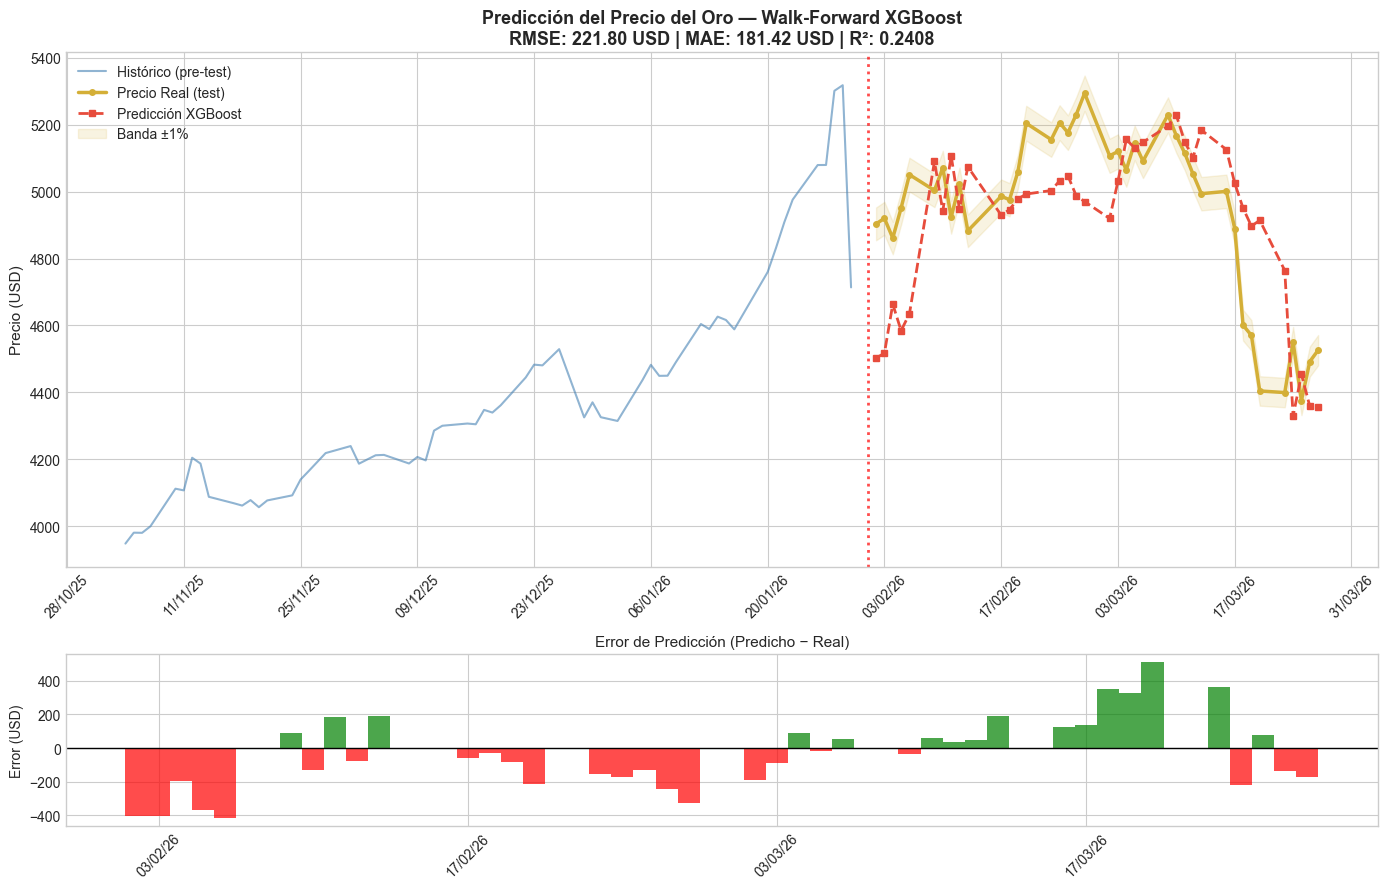

In [14]:
# ── 6.3 Gráfico de predicción vs real ────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={'height_ratios': [3, 1]})

# Panel superior: precios
ax1 = axes[0]

# Contexto previo al test (últimos 60 días de train)
pre_test = train_df.tail(60)
ax1.plot(pre_test.index, pre_test['Close'], color='steelblue', linewidth=1.5,
         alpha=0.6, label='Histórico (pre-test)')

# Test: real vs predicho
ax1.plot(results.index, results['actual'],    color='#D4AF37',  linewidth=2.5,
         marker='o', markersize=4, label='Precio Real (test)')
ax1.plot(results.index, results['predicted'], color='#E74C3C',  linewidth=2,
         marker='s', markersize=4, linestyle='--', label='Predicción XGBoost')

# Banda de confianza ±1%
ax1.fill_between(results.index,
                 results['actual'] * 0.99,
                 results['actual'] * 1.01,
                 alpha=0.15, color='#D4AF37', label='Banda ±1%')

ax1.axvline(pd.Timestamp(TEST_START), color='red', linestyle=':', linewidth=2, alpha=0.7)
ax1.set_title('Predicción del Precio del Oro — Walk-Forward XGBoost\n'
              f'RMSE: {rmse:.2f} USD | MAE: {mae:.2f} USD | R²: {r2:.4f}',
              fontsize=13, fontweight='bold')
ax1.set_ylabel('Precio (USD)', fontsize=11)
ax1.legend(loc='best', fontsize=10)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%y'))
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# Panel inferior: error
ax2 = axes[1]
errors = results['predicted'] - results['actual']
colors = ['green' if e >= 0 else 'red' for e in errors]
ax2.bar(results.index, errors, color=colors, alpha=0.7, width=1)
ax2.axhline(0, color='black', linewidth=1)
ax2.set_title('Error de Predicción (Predicho − Real)', fontsize=11)
ax2.set_ylabel('Error (USD)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%y'))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('prediccion_vs_real.png', dpi=150, bbox_inches='tight')
plt.show()

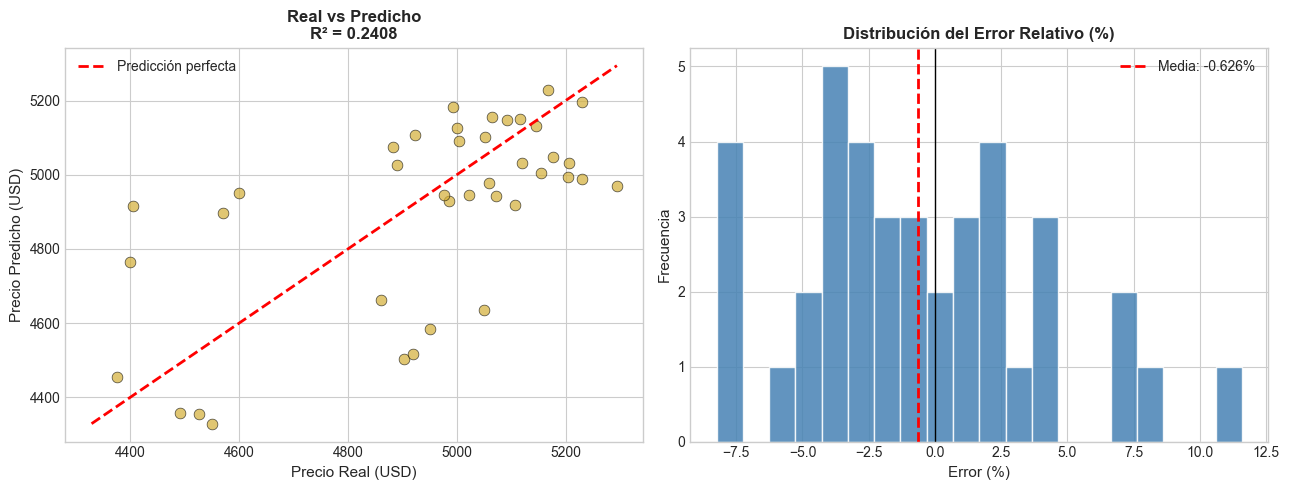

In [15]:
# ── 6.4 Scatter: Real vs Predicho ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter
ax = axes[0]
ax.scatter(results['actual'], results['predicted'], alpha=0.7, color='#D4AF37',
           edgecolors='black', linewidths=0.5, s=60)
min_val = min(results['actual'].min(), results['predicted'].min())
max_val = max(results['actual'].max(), results['predicted'].max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Predicción perfecta')
ax.set_xlabel('Precio Real (USD)', fontsize=11)
ax.set_ylabel('Precio Predicho (USD)', fontsize=11)
ax.set_title(f'Real vs Predicho\nR² = {r2:.4f}', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)

# Distribución de errores
ax2 = axes[1]
errors_pct = (results['predicted'] - results['actual']) / results['actual'] * 100
ax2.hist(errors_pct, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
ax2.axvline(errors_pct.mean(), color='red', linestyle='--', linewidth=2,
             label=f'Media: {errors_pct.mean():.3f}%')
ax2.axvline(0, color='black', linewidth=1)
ax2.set_xlabel('Error (%)', fontsize=11)
ax2.set_ylabel('Frecuencia', fontsize=11)
ax2.set_title('Distribución del Error Relativo (%)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('scatter_error.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Análisis de Features

Esta sección os ayudará a entender **qué variables está usando el modelo** y cuáles son más importantes. Usad esto para iterar y mejorar vuestras features.

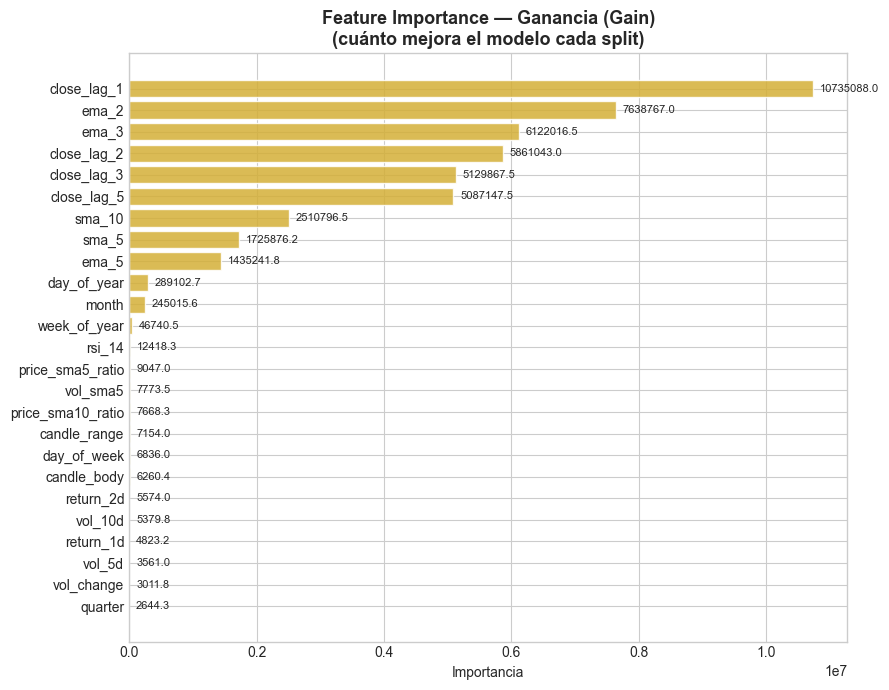

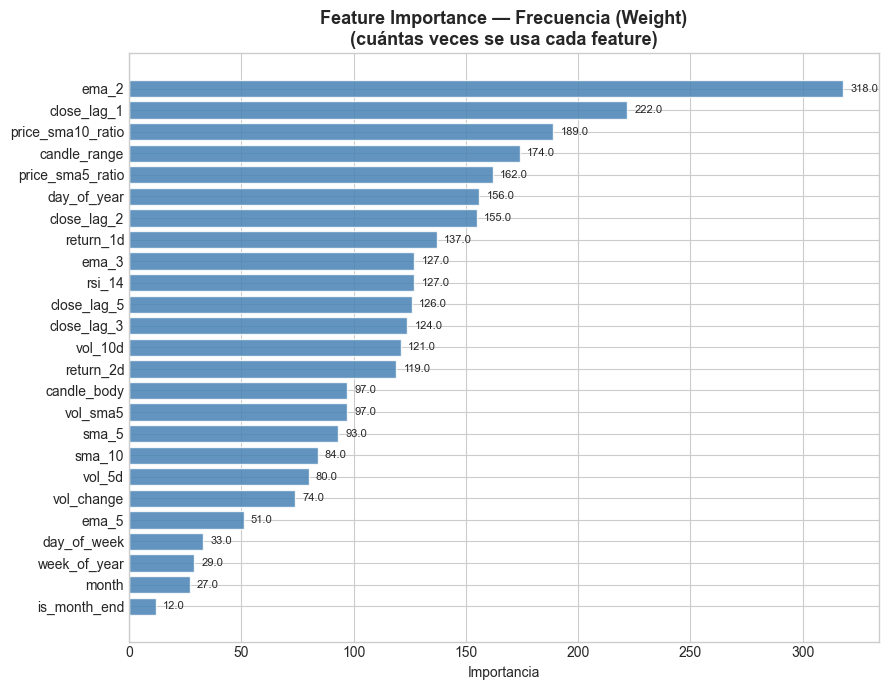

In [16]:
# ── 7.1 Feature Importance (XGBoost nativa) ──────────────────────────────────
# Usamos el último modelo entrenado
last_model = trained_models[-1]

# Importancia por ganancia (cuánto mejora cada split)
importance_gain   = last_model.get_booster().get_score(importance_type='gain')
importance_weight = last_model.get_booster().get_score(importance_type='weight')
importance_cover  = last_model.get_booster().get_score(importance_type='cover')

def plot_feature_importance(importance_dict, title, color, top_n=25):
    imp_df = pd.DataFrame.from_dict(importance_dict, orient='index', columns=['importance'])
    imp_df = imp_df.sort_values('importance', ascending=True).tail(top_n)
    
    fig, ax = plt.subplots(figsize=(9, max(6, top_n * 0.28)))
    bars = ax.barh(imp_df.index, imp_df['importance'], color=color, alpha=0.85,
                   edgecolor='white')
    
    # Añadir valores
    for bar, val in zip(bars, imp_df['importance']):
        ax.text(bar.get_width() + imp_df['importance'].max() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}', va='center', fontsize=8)
    
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_xlabel('Importancia')
    plt.tight_layout()
    return fig

fig1 = plot_feature_importance(importance_gain, 
                               'Feature Importance — Ganancia (Gain)\n(cuánto mejora el modelo cada split)',
                               '#D4AF37', top_n=25)
plt.savefig('feature_importance_gain.png', dpi=150, bbox_inches='tight')
plt.show()

fig2 = plot_feature_importance(importance_weight,
                               'Feature Importance — Frecuencia (Weight)\n(cuántas veces se usa cada feature)',
                               'steelblue', top_n=25)
plt.savefig('feature_importance_weight.png', dpi=150, bbox_inches='tight')
plt.show()

⏳ Calculando SHAP values (puede tardar unos segundos)...


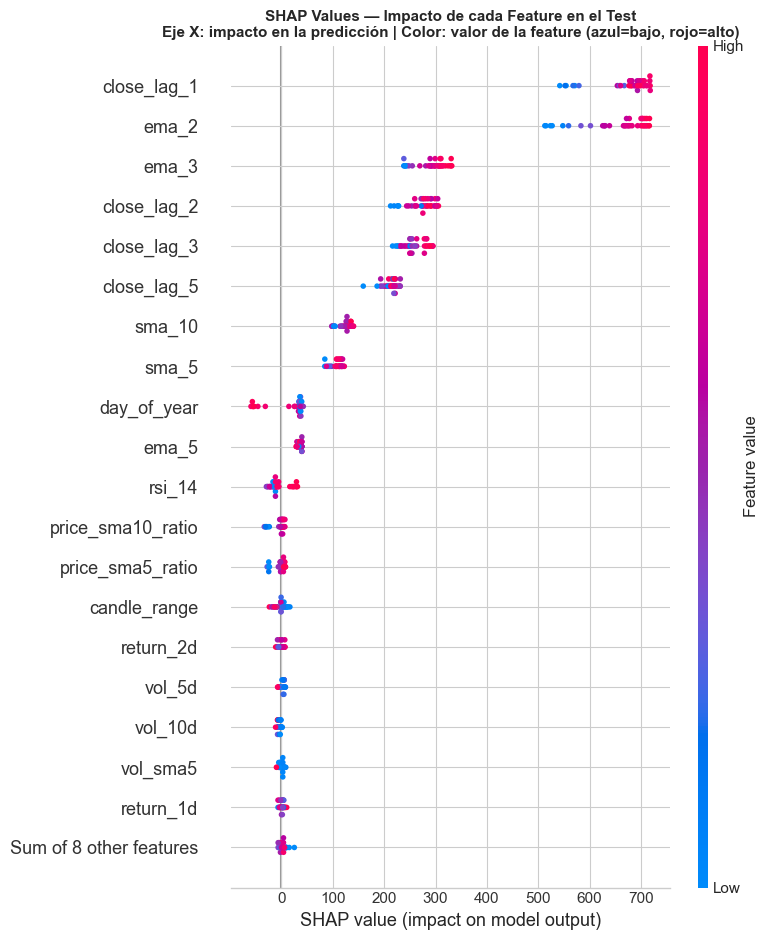

✅ SHAP calculado
💡 Las features en la parte superior son las más influyentes
   Puntos a la derecha (rojo) = valor alto de la feature → impacto positivo en predicción
   Puntos a la izquierda (azul) = valor bajo → impacto negativo


In [17]:
# ── 7.2 SHAP Values — interpretación global ──────────────────────────────────
# SHAP (SHapley Additive exPlanations) permite entender el impacto
# de cada feature en cada predicción individual

print('⏳ Calculando SHAP values (puede tardar unos segundos)...')

# Usamos el conjunto de test para calcular SHAP
X_test_shap = test_df[FEATURE_COLS].dropna()

explainer   = shap.TreeExplainer(last_model)
shap_values = explainer(X_test_shap)

# Gráfico de resumen (beeswarm)
plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.title('SHAP Values — Impacto de cada Feature en el Test\n'
          'Eje X: impacto en la predicción | Color: valor de la feature (azul=bajo, rojo=alto)',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ SHAP calculado')
print('💡 Las features en la parte superior son las más influyentes')
print('   Puntos a la derecha (rojo) = valor alto de la feature → impacto positivo en predicción')
print('   Puntos a la izquierda (azul) = valor bajo → impacto negativo')

In [18]:
# ── 7.3 SHAP — importancia media absoluta ────────────────────────────────────
shap_importance = pd.DataFrame({
    'feature'    : X_test_shap.columns,
    'mean_|shap|': np.abs(shap_values.values).mean(axis=0)
}).sort_values('mean_|shap|', ascending=False)

print('\n📋 TOP 20 Features por Importancia SHAP (media del valor absoluto):')
print('─' * 50)
for i, row in shap_importance.head(20).iterrows():
    bar = '█' * int(row['mean_|shap|'] / shap_importance['mean_|shap|'].max() * 30)
    print(f'  {row["feature"]:30s} {row["mean_|shap|"]:.4f}  {bar}')

# Features con importancia cero
zero_importance = shap_importance[shap_importance['mean_|shap|'] == 0]
if len(zero_importance) > 0:
    print(f'\n⚠️  {len(zero_importance)} features con importancia SHAP = 0 (no aportan al modelo):')
    for f in zero_importance['feature'].tolist():
        print(f'     - {f}')


📋 TOP 20 Features por Importancia SHAP (media del valor absoluto):
──────────────────────────────────────────────────
  close_lag_1                    671.4327  ██████████████████████████████
  ema_2                          655.6127  █████████████████████████████
  ema_3                          292.0070  █████████████
  close_lag_2                    273.4278  ████████████
  close_lag_3                    258.2560  ███████████
  close_lag_5                    213.6511  █████████
  sma_10                         123.2592  █████
  sma_5                          108.5460  ████
  day_of_year                    38.2070  █
  ema_5                          34.9802  █
  rsi_14                         17.8537  
  price_sma10_ratio              8.2025  
  price_sma5_ratio               7.3553  
  candle_range                   7.1301  
  return_2d                      4.2598  
  vol_5d                         4.0708  
  vol_10d                        4.0158  
  vol_sma5                       

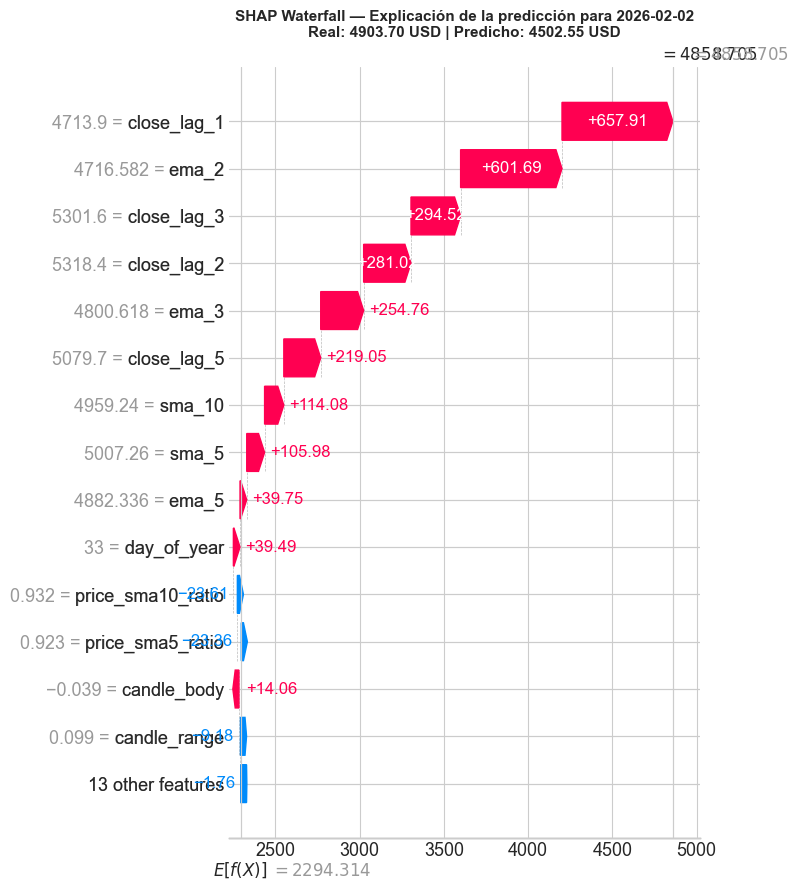

💡 Este gráfico muestra cómo cada feature suma o resta a la predicción base (E[f(x)])


In [19]:
# ── 7.4 SHAP Waterfall — explicando una predicción concreta ──────────────────
# Elegimos el primer día de test para visualizar cómo se construye esa predicción
sample_idx = 0
sample_date = X_test_shap.index[sample_idx]

plt.figure(figsize=(10, 7))
shap.plots.waterfall(shap_values[sample_idx], max_display=15, show=False)
plt.title(f'SHAP Waterfall — Explicación de la predicción para {sample_date.date()}\n'
          f'Real: {results.loc[sample_date, "actual"]:.2f} USD | '
          f'Predicho: {results.loc[sample_date, "predicted"]:.2f} USD',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Este gráfico muestra cómo cada feature suma o resta a la predicción base (E[f(x)])')

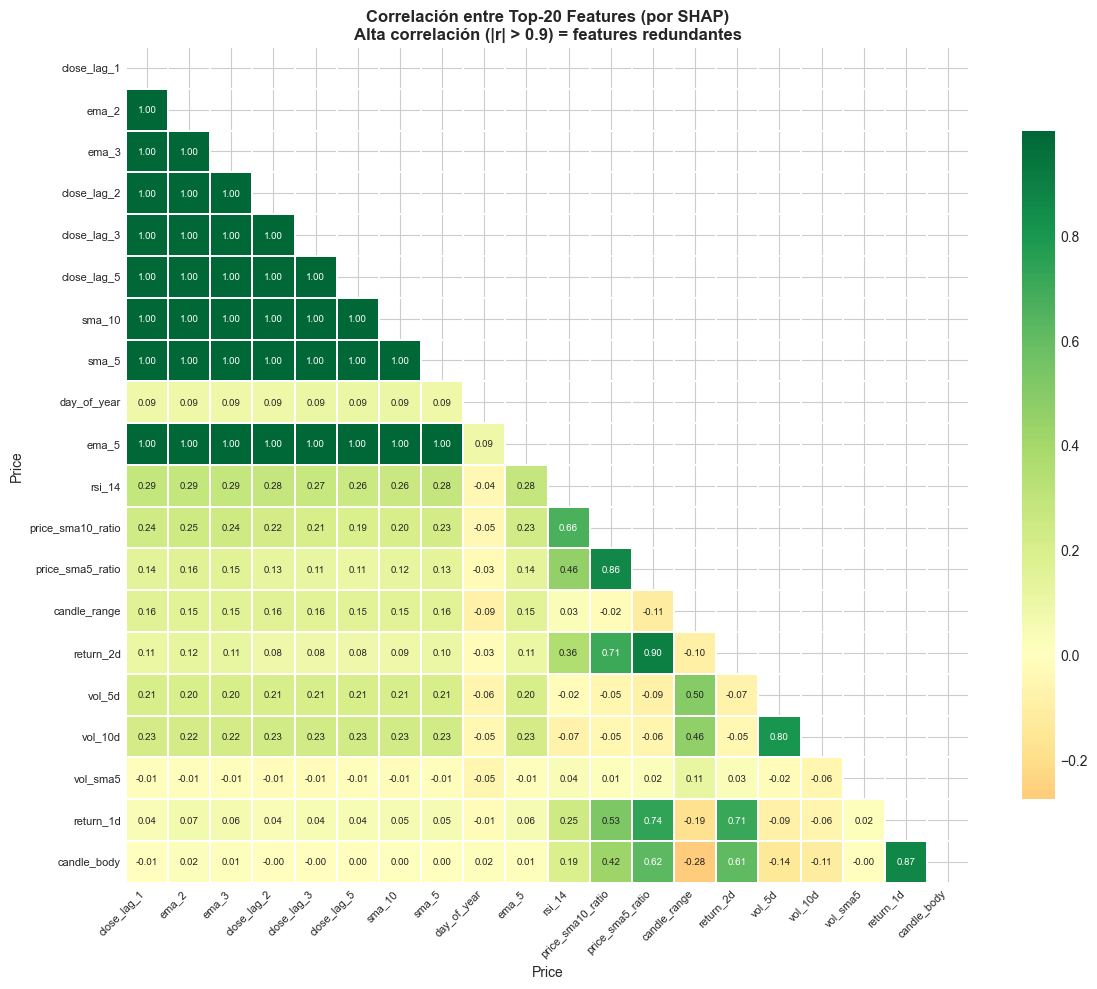

⚠️  Pares de features con correlación |r| > 0.92 (posiblemente redundantes):
   ema_2                          ↔ ema_3                           r=1.000
   sma_5                          ↔ ema_5                           r=1.000
   ema_3                          ↔ ema_5                           r=1.000
   ema_3                          ↔ sma_5                           r=1.000
   ema_2                          ↔ ema_5                           r=1.000
   close_lag_2                    ↔ sma_5                           r=1.000
   close_lag_1                    ↔ ema_3                           r=1.000
   close_lag_1                    ↔ ema_5                           r=1.000
   close_lag_3                    ↔ sma_5                           r=1.000
   close_lag_1                    ↔ sma_5                           r=1.000
   ema_2                          ↔ sma_5                           r=1.000
   close_lag_1                    ↔ ema_2                           r=1.000
   close_la

In [20]:
# ── 7.5 Correlación entre features (multicolinealidad) ──────────────────────
# Features con alta correlación pueden ser redundantes

# Usamos solo las top-20 features por importancia SHAP
top_features = shap_importance.head(20)['feature'].tolist()
corr_top     = train_df[top_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask_upper = np.triu(np.ones_like(corr_top, dtype=bool))
sns.heatmap(corr_top, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, mask=mask_upper, linewidths=0.3,
            annot_kws={'size': 7}, cbar_kws={'shrink': 0.8})
ax.set_title('Correlación entre Top-20 Features (por SHAP)\n'
             'Alta correlación (|r| > 0.9) = features redundantes',
             fontweight='bold', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('feature_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

# Identificar pares altamente correlacionados
high_corr = []
for i in range(len(corr_top.columns)):
    for j in range(i+1, len(corr_top.columns)):
        r = corr_top.iloc[i, j]
        if abs(r) > 0.92:
            high_corr.append((corr_top.columns[i], corr_top.columns[j], r))

if high_corr:
    print('⚠️  Pares de features con correlación |r| > 0.92 (posiblemente redundantes):')
    for f1, f2, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f'   {f1:30s} ↔ {f2:30s}  r={r:.3f}')
else:
    print('✅ No se detectan features altamente redundantes entre el top-20')

---
## 8. Resumen Final y Conclusiones

Completad esta celda con vuestro análisis de resultados.

In [ ]:
import pandas as pd
import os

# 1. IMPRESIÓN POR PANTALLA (Lo que quieres ver ahora)
print('═' * 65)
print('  RESUMEN FINAL DE RESULTADOS — COMPETICIÓN ORO')
print('═' * 65)
print(f'  Ticker         : {TICKER} (Gold Futures)')
print(f'  Período train : {train_df.index[0].date()} → {train_df.index[-1].date()}')
print(f'  Período test  : {TEST_START} → {TEST_END}')
print(f'  Nº features   : {len(FEATURE_COLS)}')
print(f'  Nº obs. train : {len(train_df):,}')
print(f'  Nº obs. test  : {len(results):,}')
print('─' * 65)
print(f'  RMSE          : {rmse:.4f} USD')
print(f'  MAE           : {mae:.4f} USD')
print(f'  MAPE          : {mape:.4f} %')
print(f'  R²            : {r2:.4f}')
print('─' * 65)
print(f'  Error medio (bias)    : {(results["predicted"] - results["actual"]).mean():.4f} USD')
print(f'  Días con error < 0.5% : {((results["predicted"] - results["actual"]).abs() / results["actual"] < 0.005).sum()}')
print(f'  Días con error < 1%   : {((results["predicted"] - results["actual"]).abs() / results["actual"] < 0.01).sum()}')
print('═' * 65)

# Top 5 features por SHAP
print(f'\n  TOP 5 FEATURES (por SHAP):')
for i, row in shap_importance.head(5).iterrows():
    idx = shap_importance.index.get_loc(i) + 1
    print(f'    [{idx}] {row["feature"]:35s} SHAP={row["mean_|shap|"]:.4f}')

# 2. GUARDADO EN EL HISTORIAL (Lo que guardarás para el final del trabajo)

# Extraemos la lista de las mejores variables de forma segura
top_features = shap_importance['feature'].tolist() if not shap_importance.empty else []

resumen_dict = {
    'Experimento': 'Benchmark_2',  # <-- Cambiad esto en cada prueba (ej: 'V1_Features_Grupo')
    'RMSE': rmse,
    'MAE': mae,
    'R2': r2,
    'N_Features': len(FEATURE_COLS),
    'Top_1_Feature': top_features[0] if len(top_features) > 0 else 'N/A',
    'Top_2_Feature': top_features[1] if len(top_features) > 1 else 'N/A',
    'Top_3_Feature': top_features[2] if len(top_features) > 2 else 'N/A',
    'Top_4_Feature': top_features[3] if len(top_features) > 3 else 'N/A',
    'Top_5_Feature': top_features[4] if len(top_features) > 4 else 'N/A'
}

csv_file = 'benchMark_2.csv'
if os.path.exists(csv_file):
    df_historico = pd.read_csv(csv_file)
    # Evitamos duplicados: si el nombre del experimento ya existe, lo quitamos antes de añadir el nuevo
    df_historico = df_historico[df_historico['Experimento'] != resumen_dict['Experimento']]
    df_historico = pd.concat([df_historico, pd.DataFrame([resumen_dict])], ignore_index=True)
else:
    df_historico = pd.DataFrame([resumen_dict])

df_historico.to_csv(csv_file, index=False)
print(f"\n✅ Resultados de '{resumen_dict['Experimento']}' registrados en el historial.")

# Muestra el dataframe para que veáis cómo va quedando la tabla
display(df_historico)

═════════════════════════════════════════════════════════════════
  RESUMEN FINAL DE RESULTADOS — COMPETICIÓN ORO
═════════════════════════════════════════════════════════════════
  Ticker         : GC=F (Gold Futures)
  Período train : 2020-01-23 → 2026-01-30
  Período test  : 2026-02-01 → 2026-03-31
  Nº features   : 27
  Nº obs. train : 1,515
  Nº obs. test  : 39
─────────────────────────────────────────────────────────────────
  RMSE          : 221.7982 USD
  MAE           : 181.4215 USD
  MAPE          : 3.7345 %
  R²            : 0.2408
─────────────────────────────────────────────────────────────────
  Error medio (bias)    : -36.0733 USD
  Días con error < 0.5% : 1
  Días con error < 1%   : 5
═════════════════════════════════════════════════════════════════

  TOP 5 FEATURES (por SHAP):
    [1] close_lag_1                         SHAP=671.4327
    [2] ema_2                               SHAP=655.6127
    [3] ema_3                               SHAP=292.0070
    [4] close_lag_2 

,Experimento,RMSE,MAE,R2,N_Features,Top_1_Feature,Top_2_Feature,Top_3_Feature,Top_4_Feature,Top_5_Feature
0,Benchmark_1,221.7982,181.4215,0.2408,27,close_lag_1,ema_2,ema_3,close_lag_2,close_lag_3


---

## ✏️ Conclusiones del Equipo

**Completad esta sección con vuestro análisis:**

### Features creadas

| Feature | Descripción | Impacto observado |
|---|---|---|
| `feature_1` | ... | ... |
| `feature_2` | ... | ... |

### ¿Qué features han funcionado mejor? ¿Por qué?

*Escribid aquí vuestra respuesta...*

### ¿Qué features no han funcionado? ¿Por qué creéis que no ayudan al modelo?

*Escribid aquí vuestra respuesta...*

### ¿Qué haríais diferente con más tiempo?

*Escribid aquí vuestra respuesta...*

---

*Nombre del equipo: __________*  
*Integrantes: __________*  
*Fecha de entrega: __________*